In [1]:
import tensorflow as tf
print(tf)

<module 'tensorflow' from '/usr/local/lib/python3.11/dist-packages/tensorflow/__init__.py'>


In [2]:
from tensorflow.keras import layers, models
import tensorflow as tf

# Define the model architecture
def build_model(input_shape):
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    # First convolutional hidden layer
    model.add(layers.Conv2D(64, (3, 3), strides=2, padding='same', activation='tanh'))
    model.add(layers.BatchNormalization())

    # Store the shape after the first Conv2D layer
    shape_after_conv = model.output_shape

    # Reshape for GRU input: flatten spatial dimensions into one dimension
    # The shape will be (batch_size, number_of_spatial_locations, filters)
    num_spatial_locations = shape_after_conv[1] * shape_after_conv[2]
    model.add(layers.Reshape((num_spatial_locations, shape_after_conv[-1])))

    # Second hidden layer (GRU)
    model.add(layers.GRU(256, return_sequences=True))

    # Third hidden layer (transpose convolution)
    # Reshape back to image dimensions before transpose convolution
    # We need to reshape the GRU output back into a 2D spatial arrangement
    # The target spatial dimensions should be the same as after the first Conv2D layer
    target_h = shape_after_conv[1]
    target_w = shape_after_conv[2]
    filters_after_gru = model.output_shape[-1] # This will be 256

    # Reshape to (batch_size, target_h, target_w, filters_after_gru)
    model.add(layers.Reshape((target_h, target_w, filters_after_gru)))

    model.add(layers.Conv2DTranspose(64, (3, 3), strides=2, padding='same', activation='tanh'))
    model.add(layers.BatchNormalization())

    # Final output layer
    model.add(layers.Conv2D(1, (3, 3), padding='same', activation='sigmoid'))

    return model

In [3]:
from skimage import io
from skimage.transform import resize
image = io.imread('/content/demo.jpg')
image = resize(image, (256,256))

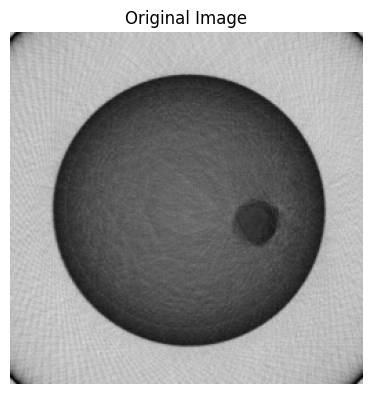

In [7]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))
# Display the original image
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')
plt.show()

In [20]:
from skimage.transform import radon
from skimage.color import rgb2gray
import numpy as np

# Convert the image to grayscale
image_gray = rgb2gray(image)

# Apply the radon transform to the grayscale image
sinogram = radon(image_gray, theta=np.linspace(0., 180., max(image_gray.shape), endpoint=False), circle = False)

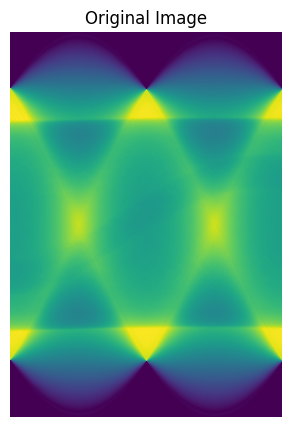

In [21]:
plt.figure(figsize=(10, 5))
# Display the original image
plt.subplot(1, 2, 1)
plt.imshow(sinogram)
plt.title('Original Image')
plt.axis('off')
plt.show()

In [23]:
# Add a channel dimension to the sinogram
sinogram_with_channel = np.expand_dims(sinogram, axis=-1)

# Build the model with the shape of the sinogram including the channel dimension
model = build_model(sinogram_with_channel.shape)

In [24]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 182, 128, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 182, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 23296, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 23296, 256)     │       247,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 182, 128, 256)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 364, 256, 64)   │       147,520 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 364, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 364, 256, 1)    │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 396,545 (1.51 MB)

 Trainable params: 396,289 (1.51 MB)

 Non-trainable params: 256 (1.00 KB)

### Displaying Prediction on sample input

In [25]:
# Add a batch dimension to the sinogram for prediction
sinogram_with_batch = np.expand_dims(sinogram_with_channel, axis=0)

# Make a prediction using the model
prediction_sinogram = model.predict(sinogram_with_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


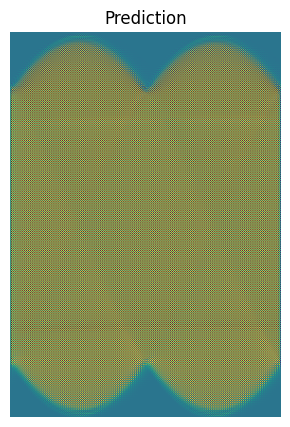

In [27]:
# Remove the batch dimension and single channel dimension from the prediction
# np.squeeze removes dimensions of size 1
prediction_to_plot = np.squeeze(prediction_sinogram)

plt.figure(figsize=(10, 5))
# Display the prediction
plt.subplot(1, 1, 1) # Use 1,1,1 for a single plot
plt.imshow(prediction_to_plot) # Use gray colormap for single channel
plt.title('Prediction')
plt.axis('off')
plt.show()

### Preparing training and testing datasets

In [ ]:
import os
base_dir = '.'
dataset = 'brain_CT'
output_folder = os.path.join(base_dir, dataset)
input_folder = os.path.join(base_dir, f"{dataset}_SINOGRAMS")